# Convexity And Parallel Shifts in Yields to Maturity

Duration and convexity measure how bond prices are affected by changes in interest rates.  Duration measures the direction and convexity, the volatility.  Both measures are mathematical calculations that follow from the present value formula. As dicussed in Chapter Seven, duration is thought of as a measure of the riskiness of a bond to changes in interest rate. As noted in that chapter, it provides an accurate ranking of the interest rate risk of bonds for small parallel changes in interest rates.  As noted, changes in interest rates often result from a change in the shape or slope of the term structure of interest rates. Duration will misclassify the riskiness of bonds for changes due to variations in the shape or slope of the term structure.

We illustrate the convexity effect using a number of simulations. In this notebook we consider the pricing behavior of a portfolio of two bonds that have different durations and convexities. The bonds are used to create a zero duration - long convexity position and profits are calculated for changes in the bonds' yields to maturity. In this notebook the yield changes are modeled as parallel shifts in the term structure. For example, all the spot rates are increased or decreased by the same amount. In the two notebooks that follow the yield curve change assumptions are compared to historical data and then altered to include more complex scenarios.

One quick caution. Because duration and convexity are inextricably linked conceptually, readers are well served by completing [Chapter Seven](https://patrickjhess.github.io/Vol-3-Chap-7/Measuring_Interest_Rate_Risk_With_Duration.html#application-calculate-duration-with-different-maturities-coupons-and-rates) before beginning this chapter.

## Preparing the notebook

### Importing libraries and functions
It's good practice to import all required libraries and modules in the first code cell of a notebook. A practice followed here. If a library is already installed, it's imported to the notebook.  If a library is not installed, it is installed and then imported.

The standard Python installation includes the first five imports: (<font color='green'>os, sys</font>, <font color='green'>requests</font>, <font color='green'>types</font>, and <font color='green'>datetime</font> and <font color='green'>dateutil</font>).  <font color='green'>os</font> and <font color='green'>sys</font>  facilitate interaction with the operating system.  The <font color='green'>requests</font> module enables sending and retrieving data from external URL addresses; in this notebook, it's specifically used to access files from DropBox. The <font color='green'>types</font> module creates the module from the Python code accessed from DropBox.  <font color='green'>datetime</font> and <font color='green'>dateutil</font> create and manipulate datetime objects.


In [ ]:
import os
import sys
import requests
from types import ModuleType
from datetime import datetime, date
from dateutil.relativedelta import relativedelta
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd

## The function <font color='green'>calc_convexity</font>
The <font color='green'>calc_convexity</font> function is structurally the same as the <font color='green'>calc_duration</font> function, with key differences in how they utilize the results of the helper function <font color='green'>bond_pv</font>.

Both functions require identical arguments.  
The <font color='green'>calc_duration</font> function calculates the bond's present value and its first derivative using <font color='green'>bond_pv</font>:

```py
# calculate present value and first derivative
value,derivative_first,_=bond_pv(rates=rates,data_dict=data_dict)

# calculate duration and return value
duration=-derivative_first/value
return duration
```

The <font color='green'>calc_convexity</font>  function ignores the first derivative and instead focuses on the present value and the second derivative:

```py
# calculate present value and second derivative
value,_,derivative_second=bond_pv(rates=rates,data_dict=data_dict)

# calculate convexity and return value
convexity=derivative_second/value
return convexity
```
Arguments must be passed for the bond's price, maturity, and coupon.  Settlement defaults to the current date and the frequency of payment to semi-annual.

 Arguments must be:

*   maturity and settlement must be date or datetime objects
*   price and coupon must be floating points or integers
*   frequency must be an integer 1 ,2, 4, or 12.

## Adding a custom module and importing functions



The <font color='green'>module_basic_concepts_fixed_income</font> custom module contains functions utilized in the notebooks within the "Basic Concepts of Fixed Income" volume. This module is accessed from Dropbox using <font color='green'>requests</font>.

You have the flexibility to choose the module name; in this instance,  <font color='green'>basic_concepts_fixed_income</font> is assigned to  <font color='green'>module_name</font>. The URL for access is provided by Dropbox. The module is instantiated with  <font color='green'>ModuleType</font> using the chosen  <font color='green'>module_name</font>. Once created, the module becomes accessible in the notebook's memory, though it is not added to a drive.
```
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='module_basic_concepts_fixed_income'
try:
  response=requests.get(url)
  module=ModuleType(module_name)

```
The <font color='green'>exec()</font> function executes the Python code returned by <font color='green'>request.get()</font>. It assigns functions and variables to <font color='green'>sys.module[module_name]</font>, making the module available to the notebook.
```
exec(response.text,module.__dict__)
sys.module[module_name]=module
```
Five functions are imported from the module including a new <font color='green'>calc_convexity</font>.  The only change between <font color='green'>calc_duration</font> and <font color='green'>calc_convexity</font> is return of the second derivative from <font color='green'>bond_pv</font>:


* **bond_pay_data** ([Chapter Three](https://patrickjhess.github.io/Vol-3-Chap-2-Chap-3/Bond_Pay_Dates.html#bond-payment-dates)): Returns the payment dates and amounts.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/bond_pay_data.html#bond-pay-data-helper-function)


* **bond_pv** ([Chapter Six](https://patrickjhess.github.io/Vol-3-Chap-6/Calculating_Yields_To_Maturity.html#demonstrating-bond-pv)): Returns the present value of a bond.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/bond_pv.html)

* **calc_duration**  ([Chapter Seven](https://patrickjhess.github.io/Vol-3-Chap-7/Measuring_Interest_Rate_Risk_With_Duration.html#application-calculate-duration-with-different-maturities-coupons-and-rates)) Calculates duration
    * [View Details](https://patrickjhess.github.io/Imported-Functions/calc_duration.html)

* **calc_convexity** (This chapter): Calculates convexity
    * [View Details](https://patrickjhess.github.io/Imported-Functions/calc_convexity.html#)

* **one_y_axis** ([Chapter One](https://patrickjhess.github.io/Vol-3-Chap-1/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.html#graphing-the-spot-and-forward-rates-for-september-30-2025)): Plots multiple series against a single x axis.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/one_y_axis.html)

  
```
# calculate present value, ignore first derivative and assign second
value,_,derivative_second=bond_pv(rates=rates,data_dict=data_dict)

# calculate convexity and return value
convexity=derivative_second/value
return convexity
```


```
from basic_concepts_fixed_income import(bond_pay_data,
                                        bond_pv,
                                        calc_duration,
                                        calc_convexity,
                                        one_y_axis)
```



In [ ]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
  response=requests.get(url)
  # Raise an exception for bad status codes (like 404 Not Found)
  response.raise_for_status()
  module= ModuleType(module_name)
  #Code contained in response.text executed
  exec(response.text, module.__dict__)
  # Module added to sys
  sys.modules[module_name]=module
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
# Open the local file in "write binary" ('wb') mode and save the downloaded content.
# Using a 'with' statement ensures the file is properly closed after writing.

# Now that 'basic_concepts_fixed_income' exists in the notebook, import the specific functions
from basic_concepts_fixed_income import(bond_pay_data,
                                        bond_pv,
                                        calc_duration,
                                        calc_convexity,
                                        one_y_axis)

## Demonstrating the effect of convexity with two bonds
A zero-duration-long-convexity trade is neutral to the direction of interest rate changes, yet it profits from any fluctuation in interest rates. The convexity trade is illustrated using an eight-year bond with a 2.758% coupon and a thirty-year bond with a 2.25% coupon. The strategy takes a long position in the higher convexity thirty-year bond and a short position in the lower convexity eight-year bond. The zero-duration position is unaffected by directional movements in the yield to maturity.

<div>
<center>
<br>
<table >
  <tr>
    <th>Maturity </th>
    <th>Coupon </th>
    <th>Yield To Maturity </th>
  </tr>
    <td>Eight Years</td>
    <td>2.758</td>
    <td>4.3%</td>
    </tr>
    <td>Thirty Years</td>
    <td>2.25</td>
    <td>4.3%</td>
  </tr>
</table>
<br>
</center>
</div>

The duration, convexity, and value of the bonds are calculated with the functions <font color='green'>calc_duration, calc_convexity()</font> and <font color='green'>bond_pv()</font>.

In [ ]:
from dateutil.relativedelta import relativedelta
# define bond attributes coupons, maturities and yield to maturity
coupons=[2.758,2.25]
maturities=[date.today()+relativedelta(years=8),
            date.today()+relativedelta(years=30)]
ytm=0.043

# populate the lists durations and convexities
durations=[calc_duration(maturity,coupon,rates=ytm)
                          for maturity,coupon in zip(maturities,coupons)]
convexities=[calc_convexity(maturity,coupon,ytm)
                          for maturity,coupon in zip(maturities,coupons)]

# value the bonds using bond_pay_data for payment dates and amounts
pay_data_list=[{'pay_data':bond_pay_data(maturity,coupon)}
               for maturity,coupon in zip(maturities,coupons)]
bond_values=[bond_pv(ytm,data)[0] for data in pay_data_list]

# save calculations in DataFrame
df_duration_convexity_value=pd.DataFrame({'Duration':durations,
                                          'Convexity':convexities,
                                         'Bond Value':bond_values},
                                          index=['8 Year 2.75','30 Year 2.25'])
df_duration_convexity_value

,Duration,Convexity,Bond Value
8 Year 2.75,7.179711,0.268245,89.354452
30 Year 2.25,19.682603,0.273589,65.039609


## A zero-duration long-convexity trade

The duration of the convexity trade is zero making it immune from directional changes in interest rates. The duration of the 30-year bond is 2.741 times that of the 8-year ($\frac{19.683}{7.180})$.  To hedge directional changes in interest rates, the trade is short 2.741 dollars of the eight-year bond for every dollar invested in the 30-year.  The value of the 30-year bond is 72.8% ($\frac{65.039}{89.354})$ of the 8-year and the hedge adjusts the ratio of durations by that amount.

$$Hedge\ Ratio = \frac{19.6849}{7.17854}\times\frac{65.039}{89.354}= 1.995$$
<br>

**Mechanics of shorting a bond**

The repo market can be used to short a bond.  In a 'repo' transaction, the bond owner sells the bond with an agreement to repurchase it at a fixed price and date. Conversely, the party buying the bond and agreeing to resell it is said to have 'reverse repoed' the bond. A short position is established when the party reversing the repo sells the bond in the market and repurchases the bond at the expiration of the repo agreement.


Upon the expiration of the 'repo' agreement, the purchased bond is sold back at the agreed-upon price and date. In our example, selling 1.995 eight-year bonds resulted in an inflow of \\$178.30; buying one thirty-year bond is an outflow of $65.04.  The  net inflow is \\$113.26. The net investment of the trade is the cost of purchasing 1.995 eight-year bonds less the net inflow:


$$ \$65.04 = \$178.30 -\$113.26$$


## Calculate the gross profits of the convexity trade
The ratios of durations and bond values are calculated by dividing the second row of the <font color='green'>df_duration_convexity_value</font> DataFrame by the first and ignoring the ratio of convexities.  The hedge ratio is calculated as the product of these two ratios.  The NumPy function <font color='green'>arange()</font> is used to create the array <font color='green'>delta_ytm</font> between -0.01 and 0.01 at 0.001 increments- in total twenty-one elements. The payment dates for both bonds are calculated with <font color='green'>bond_pay_data()</font>.  Both bond values are calculated for the new yields calculated as the sum of the <font color='green'>delta_ytm</font> array and the scalar <font color='green'>ytm</font>. The values of the bonds at the original 4.3% yield to maturity are assigned to <font color='green'>ytm_8</font> and <font color='green'>ytm_30</font>.

In [ ]:
#Calculate the ratio of durations and values by dividing the 30 Year row by the 8 Year Row
#The underscore serves to ignore the ratio of convexities
duration_ratio,__,value_ratio=df_duration_convexity_value.iloc[1]/df_duration_convexity_value.iloc[0]

#Calculate the hedge ratio
hedge_ratio=duration_ratio*value_ratio

#Calculate 21 changes in yield to maturity + or - 0.1% increments brom minus to plus 1%
delta_ytm=np.arange(-0.01,0.0101,0.001)

#Get pay data for both bonds
pay_data_8,pay_data_30=(bond_pay_data(maturity,coupon) for maturity,coupon
                                       in zip(maturities,coupons))

#Calculate value of bonds for incremented yields to maturity
value_8=np.array([bond_pv(new,{'pay_data':pay_data_8})[0] for new in delta_ytm+ytm])
value_30=np.array([bond_pv(new,{'pay_data':pay_data_30})[0] for new in delta_ytm+ytm])

#4.3% ytm value of bonds
ytm_8,ytm_30=df_duration_convexity_value['Bond Value']

# P&L = (P&L of long one 30-year bond) + (P&L of short 1.996 8-year bonds)
convexity_gross_profit=value_30-ytm_30-hedge_ratio*(value_8-ytm_8)

## Graphing the gross profits of the convexity trade



 The gross profit of the trade is plotted with the function <font color='green'>one_y_axis()</font>.


❓ Do you want to save the file? (y/n) (press enter for n): n


###***❌ File Not Saved***.

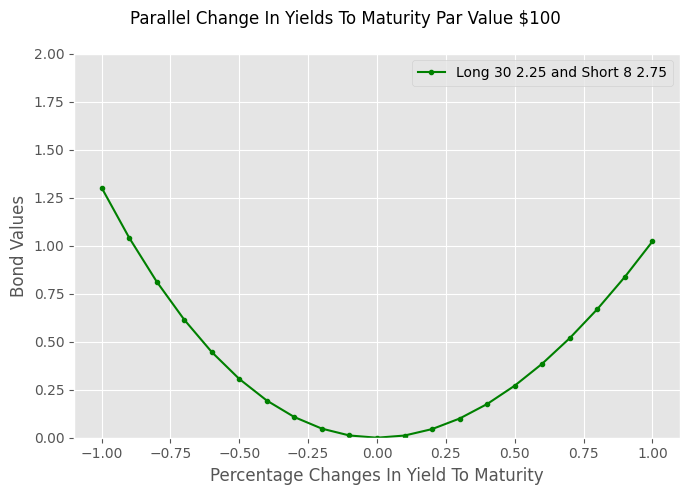

In [ ]:
#Assign x axis and data to be plotted
xaxis=delta_ytm*100
data=[convexity_gross_profit]
save_config={}
# Attempt to extract the plot title from the file name.
try:
    title = os.path.splitext(save_config['File'])[0]
#'File Name' key not found or string is too short), set a default title.
except:
    title = 'Parallel Change In Yields To Maturity Par Value $100'

#Set the appearance of the graph
series=['Long 30 2.25 and Short 8 2.75']
ylabel='Bond Values'
xlabel='Percentage Changes In Yield To Maturity'
color=['green']
lower=0
upper=2.0
markers=['.']
ylim=[lower,upper]
size=(7,5)

# This function generates and possibly saves a plot.
one_y_axis(xaxis,data,title,series,xlabel,ylabel,markers,size,ylim,
          save_config=save_config,colors=color)

For parallel shifts of the yield curve the zero-duration long-convexity trade produces gross profits for increase and decreases of the yields to maturity. However, if our assuption that market expectations of the term structure are limited to only parallel shifts, the expected gross profits will not be accurate. The notebook *Changes in Par Yields Between 1993 and 2025* presents evidence that a simple parallel shift in rates is unlikely to be a likely scenario.


## <font color='green'>Application: Calculate and graph the gross profits of the convexity trade using a 30-year and five-year bond.</font>
<br>

<div>
<center>
<br>
<table >
  <tr>
    <th>Maturity </th>
    <th>Coupon </th>
    <th>Yield To Maturity </th>
  </tr>
    <td>Five Years</td>
    <td>5.0</td>
    <td>4.3%</td>
    </tr>
    <td>Thirty Years</td>
    <td>2.25</td>
    <td>4.3%</td>
  </tr>
</table>
<br>
</center>



 see [Chapter Eight Hints: Graph gross profits of convexity trade](https://colab.research.google.com/drive/1WL30MXvTfn3tTNQaaas2bmHn3G5E3lK4#scrollTo=RMp8ZpxKRdl4), and check the [expected results here](https://colab.research.google.com/drive/1jULdrPyul6Xs5Zrm4ysXezNNuJG7K6l6#scrollTo=RMp8ZpxKRdl4).

</div>